# Student Dropout and Academic Success Prediction

## AAI-510: Machine Learning for Artificial Intelligence Final Project

In [1]:
import sys
import pandas as pd
sys.path.insert(0, '../src')

---

## 1. Problem Statement and Justification

In [2]:
from dropout.data.loader import load_dataset
df = load_dataset()
print(f"Shape: {df.shape}")
print(df['target'].value_counts())

Shape: (4424, 37)
target
Graduate    2209
Dropout     1421
Enrolled     794
Name: count, dtype: int64


In [3]:
print(df.dtypes)

Marital Status                                      int64
Application mode                                    int64
Application order                                   int64
Course                                              int64
Daytime/evening attendance                          int64
Previous qualification                              int64
Previous qualification (grade)                    float64
Nacionality                                         int64
Mother's qualification                              int64
Father's qualification                              int64
Mother's occupation                                 int64
Father's occupation                                 int64
Admission grade                                   float64
Displaced                                           int64
Educational special needs                           int64
Debtor                                              int64
Tuition fees up to date                             int64
Gender        

### 2.2 Missing Values and Data Quality

In [4]:
missing = df.isnull().sum()
print("Missing values per column:")
print(missing[missing > 0] if missing.sum() > 0 else "No missing values found.")
print(f"Total missing: {missing.sum()}")
print(f"Duplicate rows: {df.duplicated().sum()}")

Missing values per column:
No missing values found.
Total missing: 0
Duplicate rows: 0


### 2.3 Target Distribution (Class Imbalance)

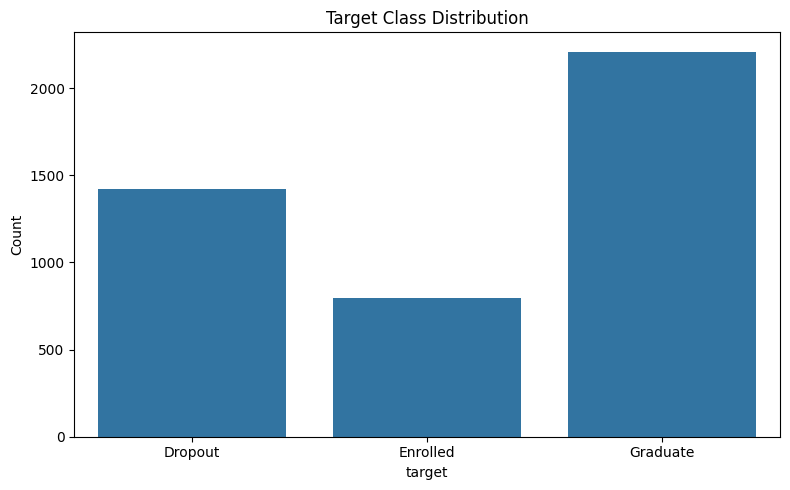

Graduate: 2209 (49.9%)
Dropout: 1421 (32.1%)
Enrolled: 794 (17.9%)


In [5]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(8, 5))
sns.countplot(data=df, x='target', order=['Dropout', 'Enrolled', 'Graduate'])
plt.title('Target Class Distribution')
plt.ylabel('Count')
plt.tight_layout()
plt.show()

for cls, count in df['target'].value_counts().items():
    print(f"{cls}: {count} ({count/len(df)*100:.1f}%)")

### 2.4 Correlation Analysis with Phi-K

interval columns not set, guessing: ['Marital Status', 'Application mode', 'Application order', 'Course', 'Daytime/evening attendance', 'Previous qualification', 'Previous qualification (grade)', 'Nacionality', "Mother's qualification", "Father's qualification", "Mother's occupation", "Father's occupation", 'Admission grade', 'Displaced', 'Educational special needs', 'Debtor', 'Tuition fees up to date', 'Gender', 'Scholarship holder', 'Age at enrollment', 'International', 'Curricular units 1st sem (credited)', 'Curricular units 1st sem (enrolled)', 'Curricular units 1st sem (evaluations)', 'Curricular units 1st sem (approved)', 'Curricular units 1st sem (grade)', 'Curricular units 1st sem (without evaluations)', 'Curricular units 2nd sem (credited)', 'Curricular units 2nd sem (enrolled)', 'Curricular units 2nd sem (evaluations)', 'Curricular units 2nd sem (approved)', 'Curricular units 2nd sem (grade)', 'Curricular units 2nd sem (without evaluations)', 'Unemployment rate', 'Inflation r

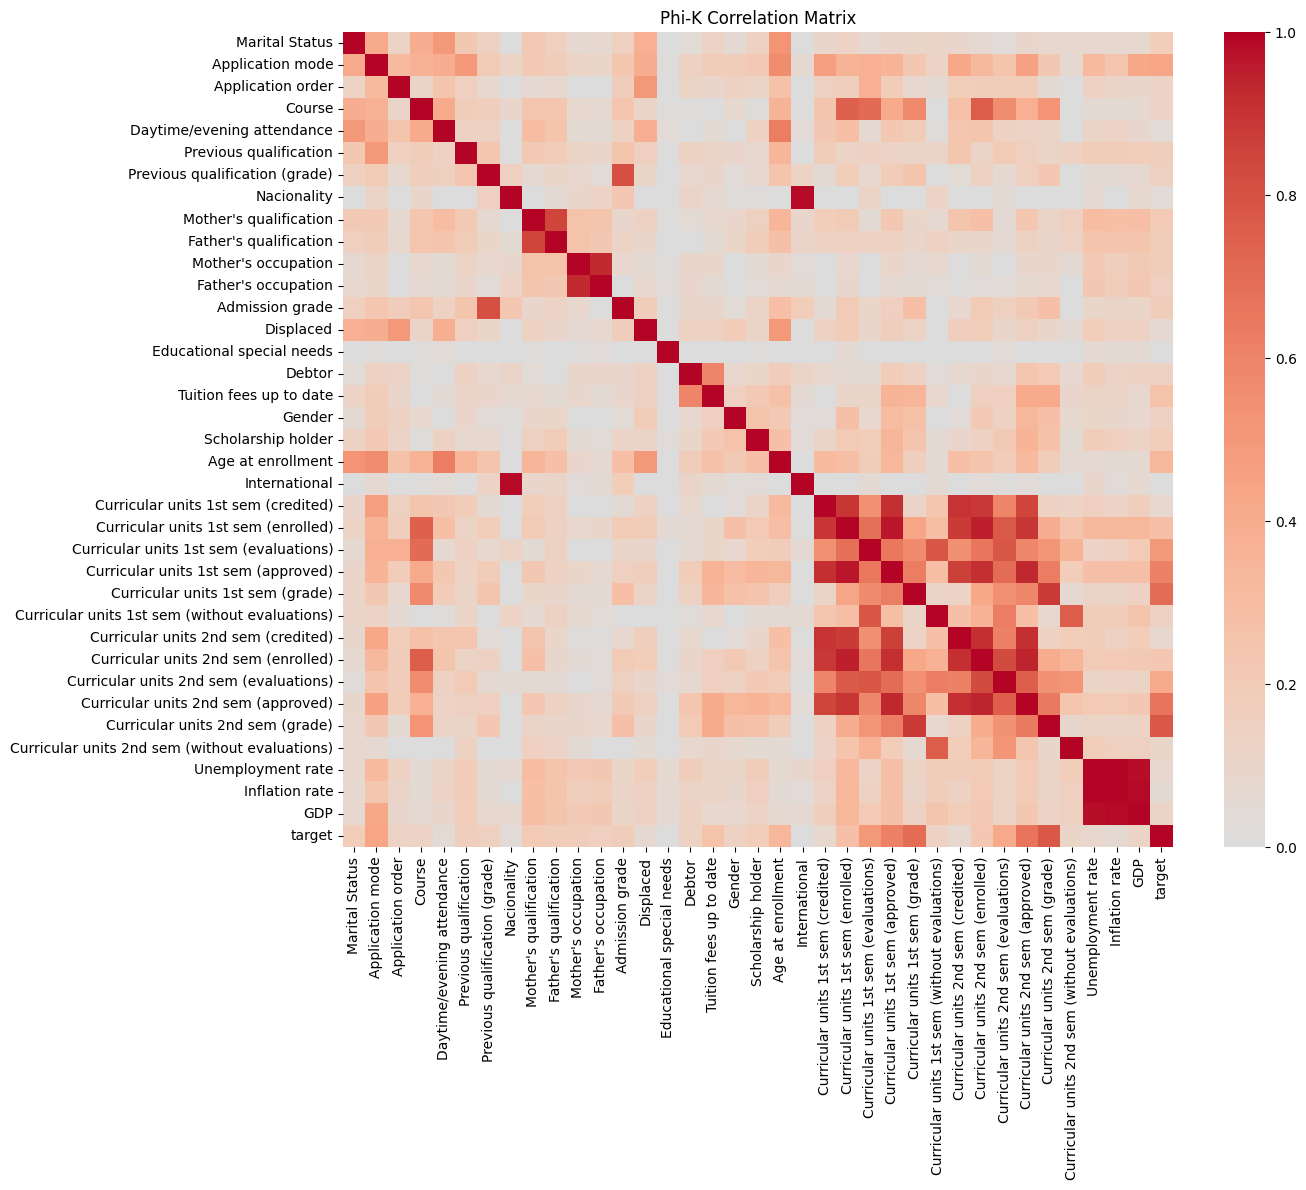

In [6]:
import phik

phik_matrix = df.phik_matrix()
plt.figure(figsize=(14, 12))
sns.heatmap(phik_matrix, annot=False, cmap='coolwarm', center=0)
plt.title('Phi-K Correlation Matrix')
plt.tight_layout()
plt.show()

### 2.5 Bivariate Analysis: Target vs. Key Predictors

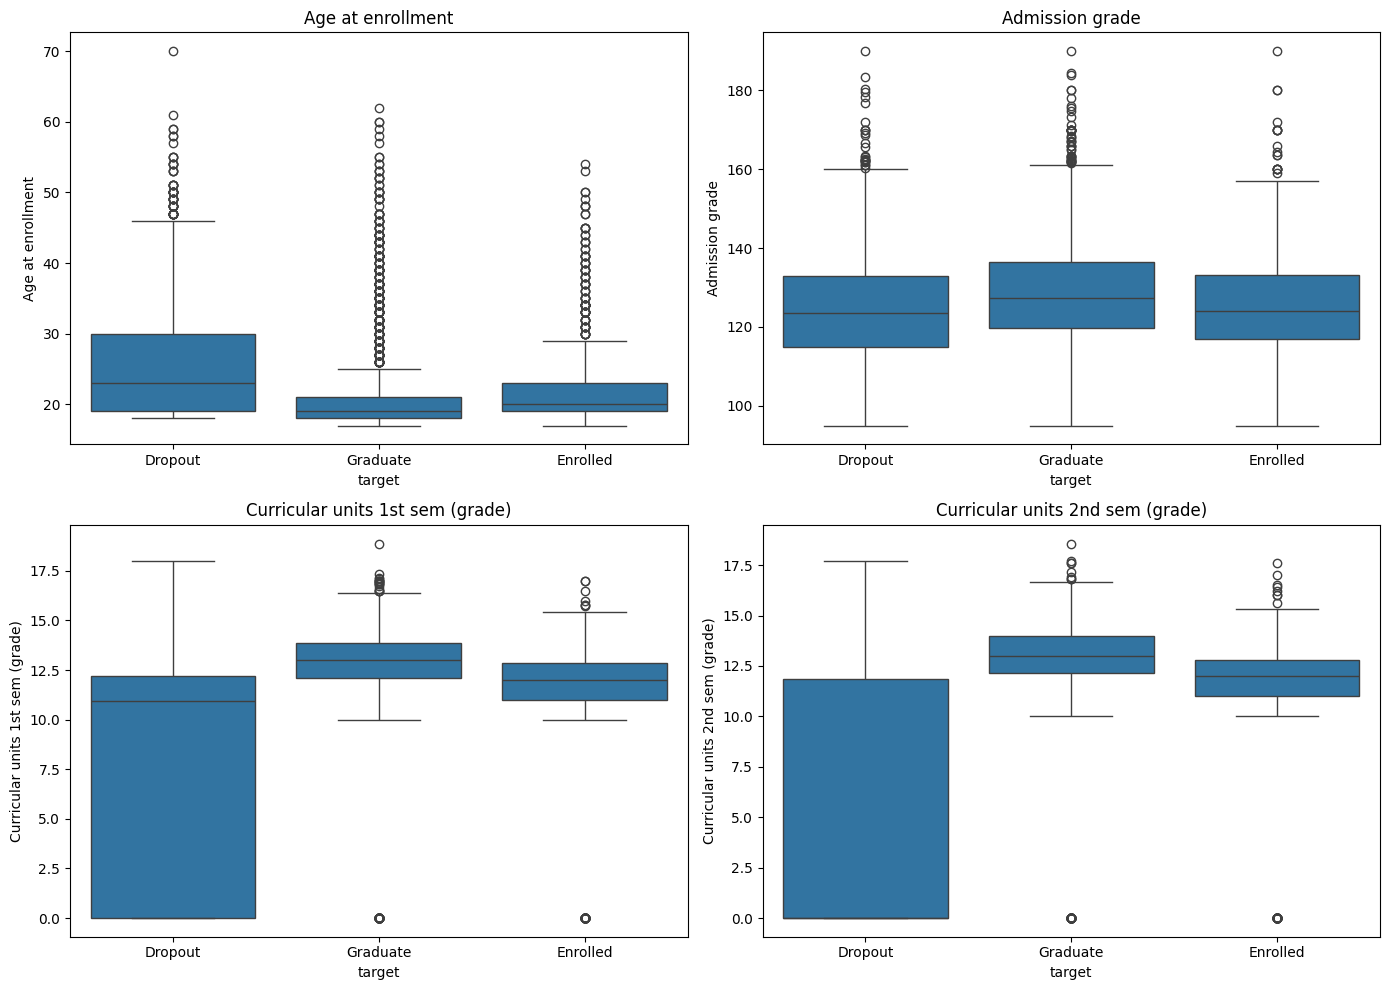

In [7]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
features = ['Age at enrollment', 'Admission grade',
            'Curricular units 1st sem (grade)',
            'Curricular units 2nd sem (grade)']
for ax, feat in zip(axes.flatten(), features):
    sns.boxplot(data=df, x='target', y=feat, ax=ax)
    ax.set_title(feat)
plt.tight_layout()
plt.show()

---

## 3. Data Preparation & Feature Engineering

In [8]:
from dropout.features.engineer import add_derived_features, build_preprocessor, ORDINAL_COLS, OHE_COLS

df_eng = add_derived_features(df)
print(f"Original features: {len(df.columns)-1}")
print(f"After engineering: {len(df_eng.columns)-1}")
print(f"Derived: {['approval_rate_s1', 'approval_rate_s2', 'grade_delta', 'financial_risk']}")

Original features: 36
After engineering: 40
Derived: ['approval_rate_s1', 'approval_rate_s2', 'grade_delta', 'financial_risk']


In [9]:
derived = ['approval_rate_s1', 'approval_rate_s2', 'grade_delta', 'financial_risk']
numeric_cols = [c for c in df_eng.columns if c not in ORDINAL_COLS + OHE_COLS + derived + ['target']] + derived
print(f"Numeric columns: {len(numeric_cols)}")
print(f"Ordinal: {len(ORDINAL_COLS)}, OHE: {len(OHE_COLS)}")
preprocessor = build_preprocessor(numeric_cols)

Numeric columns: 31
Ordinal: 7, OHE: 2


### 3.4 Train-Validation-Test Split

In [10]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from imblearn.over_sampling import SMOTE
import numpy as np

le = LabelEncoder()
y = le.fit_transform(df_eng['target'])
feature_cols = [c for c in df_eng.columns if c != 'target']
X = df_eng[feature_cols]

X_temp, X_test, y_temp, y_test = train_test_split(
    X, y, test_size=0.20, random_state=42, stratify=y
)
X_train, X_val, y_train, y_val = train_test_split(
    X_temp, y_temp, test_size=0.25, random_state=42, stratify=y_temp
)

X_train_proc = preprocessor.fit_transform(X_train)
X_val_proc = preprocessor.transform(X_val)
X_test_proc = preprocessor.transform(X_test)

smote = SMOTE(random_state=42)
X_train_sm, y_train_sm = smote.fit_resample(X_train_proc, y_train)

print(f"Train: {X_train_sm.shape[0]} samples (after SMOTE)")
print(f"Val: {X_val_proc.shape[0]} samples")
print(f"Test: {X_test_proc.shape[0]} samples")
print(f"Features after preprocessing: {X_train_proc.shape[1]}")
print(f"Classes: {le.classes_}")

Train: 3975 samples (after SMOTE)
Val: 885 samples
Test: 885 samples
Features after preprocessing: 61
Classes: ['Dropout' 'Enrolled' 'Graduate']


---

## 4. Feature Selection

Top 15 features by Gini importance:
58    0.1119
51    0.0786
57    0.0624
52    0.0600
45    0.0560
46    0.0404
60    0.0398
44    0.0331
37    0.0317
50    0.0305
40    0.0297
33    0.0295
59    0.0289
32    0.0277
1     0.0253
dtype: float64


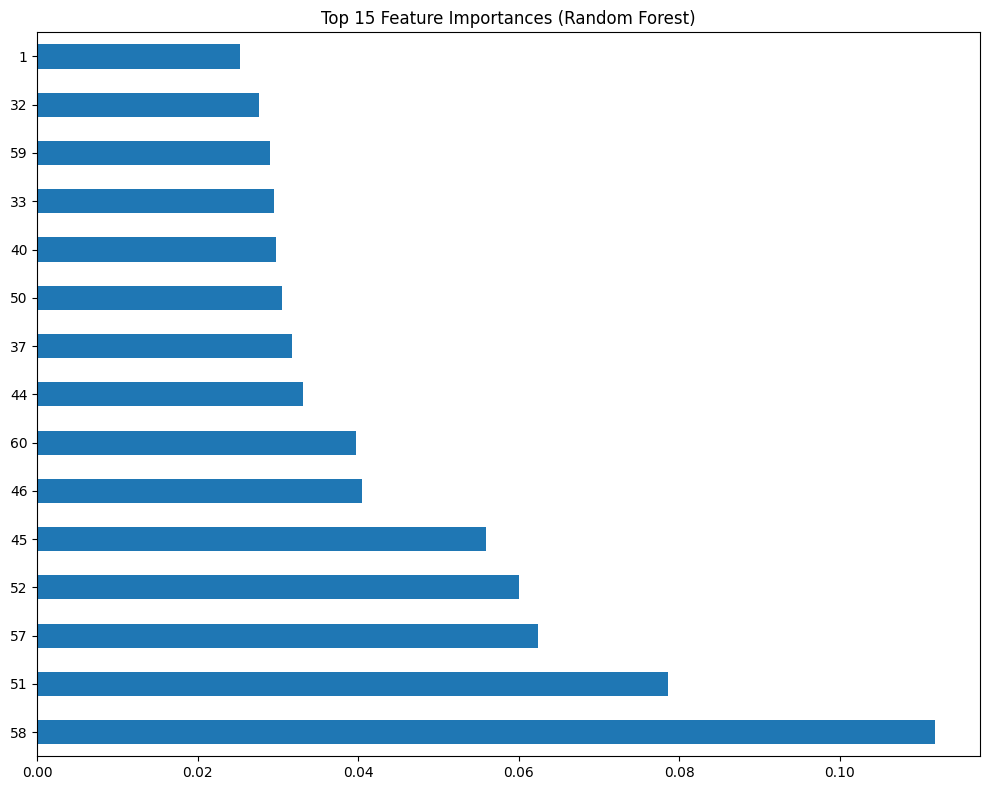

In [11]:
from sklearn.ensemble import RandomForestClassifier

rf_baseline = RandomForestClassifier(n_estimators=200, random_state=42, n_jobs=-1)
rf_baseline.fit(X_train_sm, y_train_sm)

importances = pd.Series(rf_baseline.feature_importances_).sort_values(ascending=False)
print("Top 15 features by Gini importance:")
print(importances.head(15).round(4))

plt.figure(figsize=(10, 8))
importances.head(15).plot(kind='barh')
plt.title('Top 15 Feature Importances (Random Forest)')
plt.tight_layout()
plt.show()

---

## 5. Modeling

### 5.1 Model Selection and Justification

In [12]:
import joblib
from pathlib import Path

artifact_dir = Path('../artifacts')
model = joblib.load(artifact_dir / 'model.pkl')
preprocessor_loaded = joblib.load(artifact_dir / 'preprocessor.pkl')
le_loaded = joblib.load(artifact_dir / 'label_encoder.pkl')

print(f"Best model type: {type(model).__name__}")
print(f"Model: {model}")

Best model type: StackingClassifier
Model: StackingClassifier(cv=5,
                   estimators=[('rf',
                                RandomForestClassifier(class_weight='balanced',
                                                       n_estimators=200,
                                                       n_jobs=-1,
                                                       random_state=42)),
                               ('xgb',
                                XGBClassifier(base_score=None, booster=None,
                                              callbacks=None,
                                              colsample_bylevel=None,
                                              colsample_bynode=None,
                                              colsample_bytree=0.6038527918111288,
                                              device=None,
                                              early_stopping_rounds=None,
                                              enable_categorical=Fal

### 5.2 Individual Model Training Code

In [13]:
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import f1_score

scaler = StandardScaler()
X_lr = scaler.fit_transform(X_train_sm)
lr = LogisticRegression(class_weight='balanced', max_iter=1000, random_state=42)
lr.fit(X_lr, y_train_sm)

lr_pred = lr.predict(scaler.transform(X_test_proc))
lr_f1 = f1_score(y_test, lr_pred, average='macro')
print(f"Logistic Regression Macro-F1: {lr_f1:.4f}")

rf = RandomForestClassifier(n_estimators=200, class_weight='balanced', random_state=42, n_jobs=-1)
rf.fit(X_train_sm, y_train_sm)
rf_pred = rf.predict(X_test_proc)
rf_f1 = f1_score(y_test, rf_pred, average='macro')
print(f"Random Forest Macro-F1: {rf_f1:.4f}")

Logistic Regression Macro-F1: 0.6850
Random Forest Macro-F1: 0.7067


In [14]:
import optuna
import xgboost as xgb

optuna.logging.set_verbosity(optuna.logging.WARNING)

def xgb_objective(trial):
    params = dict(
        n_estimators=trial.suggest_int('n_estimators', 100, 400),
        max_depth=trial.suggest_int('max_depth', 3, 8),
        learning_rate=trial.suggest_float('learning_rate', 0.01, 0.3, log=True),
        subsample=trial.suggest_float('subsample', 0.6, 1.0),
        colsample_bytree=trial.suggest_float('colsample_bytree', 0.6, 1.0),
    )
    m = xgb.XGBClassifier(**params, objective='multi:softprob', num_class=3,
                          random_state=42, n_jobs=-1, verbosity=0)
    m.fit(X_train_sm, y_train_sm, eval_set=[(X_val_proc, y_val)], verbose=False)
    return f1_score(y_val, m.predict(X_val_proc), average='macro')

study_xgb = optuna.create_study(direction='maximize')
study_xgb.optimize(xgb_objective, n_trials=50, show_progress_bar=True)
print(f"XGBoost best params: {study_xgb.best_params}")
print(f"XGBoost best val F1: {study_xgb.best_value:.4f}")

best_xgb = xgb.XGBClassifier(**study_xgb.best_params, objective='multi:softprob',
                              num_class=3, random_state=42, n_jobs=-1, verbosity=0)
best_xgb.fit(X_train_sm, y_train_sm)
xgb_pred = best_xgb.predict(X_test_proc)
xgb_f1 = f1_score(y_test, xgb_pred, average='macro')
print(f"XGBoost Test Macro-F1: {xgb_f1:.4f}")

  0%|          | 0/50 [00:00<?, ?it/s]

XGBoost best params: {'n_estimators': 189, 'max_depth': 3, 'learning_rate': 0.05640072479390462, 'subsample': 0.8788248119646198, 'colsample_bytree': 0.6053690740566892}
XGBoost best val F1: 0.7326
XGBoost Test Macro-F1: 0.6969


In [15]:
from lightgbm import LGBMClassifier

def lgb_objective(trial):
    params = dict(
        n_estimators=trial.suggest_int('n_estimators', 100, 400),
        num_leaves=trial.suggest_int('num_leaves', 20, 120),
        learning_rate=trial.suggest_float('learning_rate', 0.01, 0.3, log=True),
        min_child_samples=trial.suggest_int('min_child_samples', 5, 40),
        subsample=trial.suggest_float('subsample', 0.6, 1.0),
    )
    m = LGBMClassifier(**params, objective='multiclass', num_class=3,
                       class_weight='balanced', verbose=-1, random_state=42, n_jobs=-1)
    m.fit(X_train_sm, y_train_sm, eval_set=[(X_val_proc, y_val)])
    return f1_score(y_val, m.predict(X_val_proc), average='macro')

study_lgb = optuna.create_study(direction='maximize')
study_lgb.optimize(lgb_objective, n_trials=50, show_progress_bar=True)
print(f"LightGBM best params: {study_lgb.best_params}")
print(f"LightGBM best val F1: {study_lgb.best_value:.4f}")

best_lgb = LGBMClassifier(**study_lgb.best_params, objective='multiclass',
                           num_class=3, class_weight='balanced', verbose=-1,
                           random_state=42, n_jobs=-1)
best_lgb.fit(X_train_sm, y_train_sm)
lgb_pred = best_lgb.predict(X_test_proc)
lgb_f1 = f1_score(y_test, lgb_pred, average='macro')
print(f"LightGBM Test Macro-F1: {lgb_f1:.4f}")

  0%|          | 0/50 [00:00<?, ?it/s]

/Users/sourangshupal/Downloads/student-dropout-project/.venv/lib/python3.12/site-packages/sklearn/utils/validation.py:2691: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/Users/sourangshupal/Downloads/student-dropout-project/.venv/lib/python3.12/site-packages/sklearn/utils/validation.py:2691: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/Users/sourangshupal/Downloads/student-dropout-project/.venv/lib/python3.12/site-packages/sklearn/utils/validation.py:2691: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/Users/sourangshupal/Downloads/student-dropout-project/.venv/lib/python3.12/site-packages/sklearn/utils/validation.py:2691: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/Users/sourangshupal/Downloads/student-d

LightGBM best params: {'n_estimators': 122, 'num_leaves': 31, 'learning_rate': 0.014373769426388398, 'min_child_samples': 27, 'subsample': 0.833085324941707}
LightGBM best val F1: 0.7280
LightGBM Test Macro-F1: 0.7088


/Users/sourangshupal/Downloads/student-dropout-project/.venv/lib/python3.12/site-packages/sklearn/utils/validation.py:2691: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


In [16]:
from sklearn.ensemble import StackingClassifier
from sklearn.linear_model import LogisticRegression

meta = LogisticRegression(max_iter=500, random_state=42)
stack = StackingClassifier(
    estimators=[('rf', rf), ('xgb', best_xgb), ('lgb', best_lgb)],
    final_estimator=meta, cv=5, n_jobs=-1
)
stack.fit(X_train_sm, y_train_sm)
stack_pred = stack.predict(X_test_proc)
stack_f1 = f1_score(y_test, stack_pred, average='macro')
print(f"Stacking Test Macro-F1: {stack_f1:.4f}")

/Users/sourangshupal/Downloads/student-dropout-project/.venv/lib/python3.12/site-packages/sklearn/utils/validation.py:2691: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/Users/sourangshupal/Downloads/student-dropout-project/.venv/lib/python3.12/site-packages/sklearn/utils/validation.py:2691: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/Users/sourangshupal/Downloads/student-dropout-project/.venv/lib/python3.12/site-packages/sklearn/utils/validation.py:2691: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/Users/sourangshupal/Downloads/student-dropout-project/.venv/lib/python3.12/site-packages/sklearn/utils/validation.py:2691: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/Users/sourangshupal/Downloads/student-d

Stacking Test Macro-F1: 0.7036


/Users/sourangshupal/Downloads/student-dropout-project/.venv/lib/python3.12/site-packages/sklearn/utils/validation.py:2691: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


Model Comparison (Test Set):
              Model  Macro_F1
           LightGBM  0.708841
      Random Forest  0.706691
           Stacking  0.703633
            XGBoost  0.696941
Logistic Regression  0.685027


/var/folders/cj/13vbmk7n7fqgmdnqjjwn1bx80000gn/T/ipykernel_7205/2677006171.py:10: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=results, x='Macro_F1', y='Model', palette='viridis')


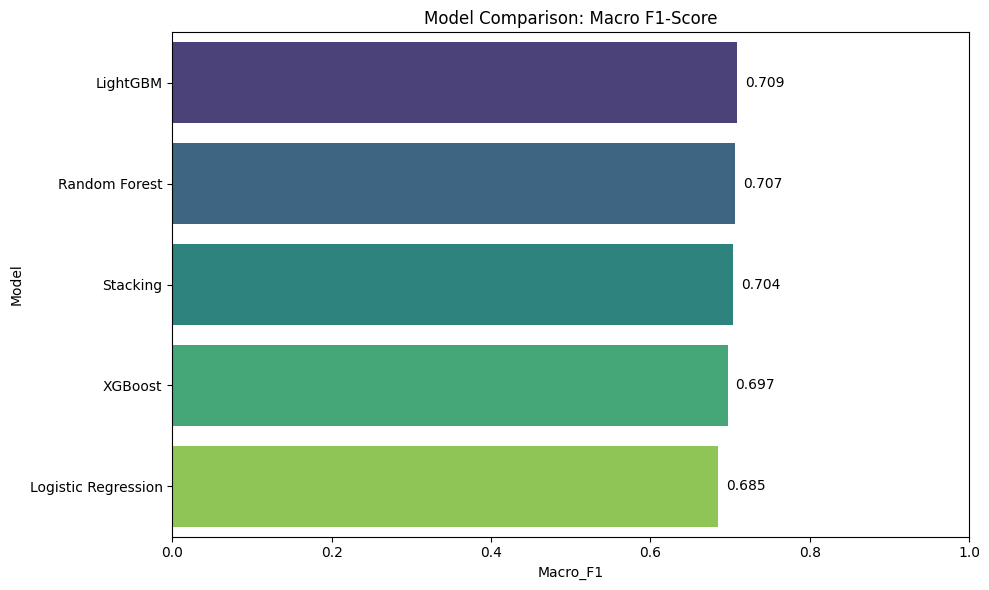

In [17]:
results = pd.DataFrame({
    'Model': ['Logistic Regression', 'Random Forest', 'XGBoost', 'LightGBM', 'Stacking'],
    'Macro_F1': [lr_f1, rf_f1, xgb_f1, lgb_f1, stack_f1]
}).sort_values('Macro_F1', ascending=False)

print("Model Comparison (Test Set):")
print(results.to_string(index=False))

plt.figure(figsize=(10, 6))
sns.barplot(data=results, x='Macro_F1', y='Model', palette='viridis')
plt.title('Model Comparison: Macro F1-Score')
plt.xlim(0, 1)
for i, v in enumerate(results['Macro_F1']):
    plt.text(v + 0.01, i, f'{v:.3f}', va='center')
plt.tight_layout()
plt.show()

---

## 6. Evaluation

/Users/sourangshupal/Downloads/student-dropout-project/.venv/lib/python3.12/site-packages/sklearn/utils/validation.py:2691: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


Classification Report:
              precision    recall  f1-score   support

     Dropout       0.79      0.78      0.78       284
    Enrolled       0.51      0.48      0.50       159
    Graduate       0.84      0.86      0.85       442

    accuracy                           0.76       885
   macro avg       0.71      0.71      0.71       885
weighted avg       0.76      0.76      0.76       885



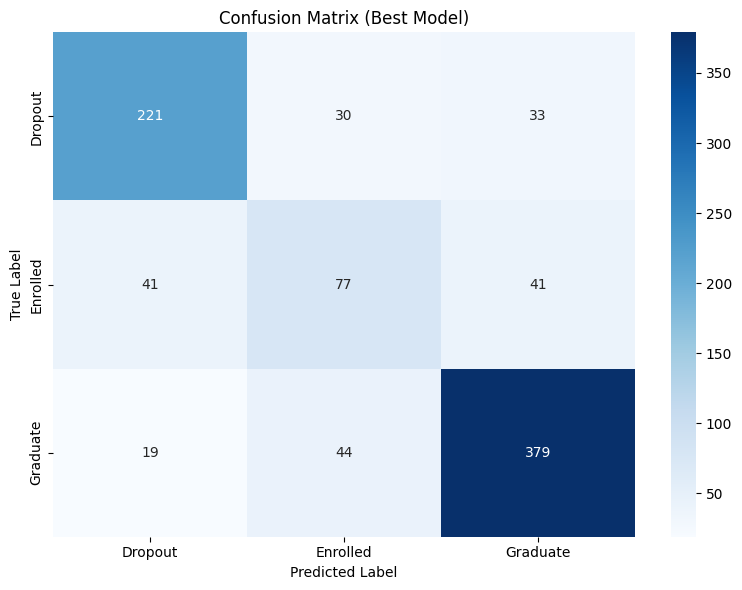

In [18]:
from sklearn.metrics import classification_report, confusion_matrix

best_pred = model.predict(X_test_proc)
print("Classification Report:")
print(classification_report(y_test, best_pred, target_names=le_loaded.classes_))

cm = confusion_matrix(y_test, best_pred)
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=le_loaded.classes_,
            yticklabels=le_loaded.classes_)
plt.title('Confusion Matrix (Best Model)')
plt.ylabel('True Label')
plt.xlabel('Predicted Label')
plt.tight_layout()
plt.show()

### 6.3 SHAP Explainability

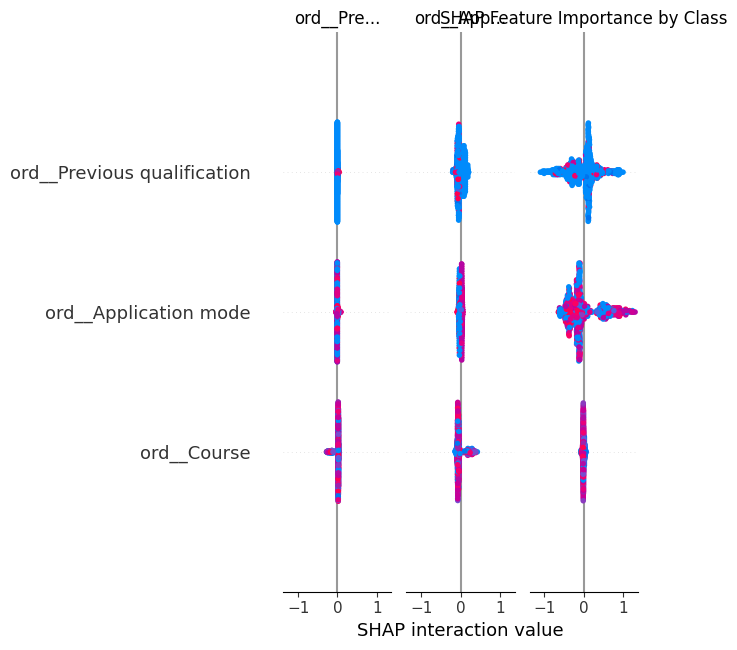

In [19]:
import shap

explainer = shap.TreeExplainer(best_xgb)
shap_values = explainer.shap_values(X_test_proc)

shap.summary_plot(shap_values, X_test_proc, feature_names=preprocessor.get_feature_names_out(),
                  class_names=le_loaded.classes_, show=False)
plt.title('SHAP Feature Importance by Class')
plt.tight_layout()
plt.show()

---

## 7. Deployment

In [20]:
import requests

try:
    response = requests.get('http://localhost:8000/health')
    print(f"API Status: {response.json()}")
except requests.exceptions.ConnectionError:
    print("FastAPI server not running. Start with:")
    print("  uv run uvicorn dropout.api.main:app --port 8000")

FastAPI server not running. Start with:
  uv run uvicorn dropout.api.main:app --port 8000


In [21]:
payload = {
    "marital_status": 1, "gender": 1, "age_at_enrollment": 20,
    "nationality": 1, "international": 0,
    "application_mode": 1, "application_order": 1, "course": 1,
    "daytime_evening_attendance": 1,
    "previous_qualification": 1, "previous_qualification_grade": 130.0,
    "admission_grade": 130.0, "displaced": 0,
    "mothers_qualification": 1, "fathers_qualification": 1,
    "mothers_occupation": 1, "fathers_occupation": 1,
    "educational_special_needs": 0, "debtor": 0,
    "tuition_fees_up_to_date": 1, "scholarship_holder": 0,
    "curricular_units_1st_sem_credited": 0,
    "curricular_units_1st_sem_enrolled": 6,
    "curricular_units_1st_sem_evaluations": 6,
    "curricular_units_1st_sem_approved": 6,
    "curricular_units_1st_sem_grade": 12.0,
    "curricular_units_1st_sem_without_evaluations": 0,
    "curricular_units_2nd_sem_credited": 0,
    "curricular_units_2nd_sem_enrolled": 6,
    "curricular_units_2nd_sem_evaluations": 6,
    "curricular_units_2nd_sem_approved": 6,
    "curricular_units_2nd_sem_grade": 13.0,
    "curricular_units_2nd_sem_without_evaluations": 0,
    "unemployment_rate": 10.0, "inflation_rate": 1.5, "gdp": 1.0
}

try:
    response = requests.post('http://localhost:8000/predict', json=payload, timeout=10)
    result = response.json()
    print("Prediction Result:")
    for k, v in result.items():
        print(f"  {k}: {v}")
except requests.exceptions.ConnectionError:
    print("FastAPI server not running. Cannot demonstrate live prediction.")

FastAPI server not running. Cannot demonstrate live prediction.


---

## 8. Conclusions

In [22]:
print(f"Dataset shape: {df.shape}")
print(f"Engineered features: {len(df_eng.columns)-1}")
print(f"Preprocessed features: {X_train_proc.shape[1]}")
print(f"Best model: {type(model).__name__}")
print(f"Test Macro-F1 (best): {f1_score(y_test, best_pred, average='macro'):.4f}")
print(f"Classes: {list(le_loaded.classes_)}")

Dataset shape: (4424, 37)
Engineered features: 40
Preprocessed features: 61
Best model: StackingClassifier
Test Macro-F1 (best): 0.7087
Classes: ['Dropout', 'Enrolled', 'Graduate']
